## Character Embeddings

### Creating Sample Character Embeddings
Source: https://www.mlwithramin.com/blog/embeddings

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Sequential

words = [
    "hello",
    "world",
    "machine",
    "learning",
    "deep",
    "learning",
]

# Create a character-level tokenizer
tokenizer = Tokenizer(char_level=True)

# fit_on_texts creates a dictionary mapping each unique character to an integer
tokenizer.fit_on_texts(words)
char_index = tokenizer.word_index
print('Character to Integer mapping', char_index)

# Encode words as a sequence of integers
sequences = tokenizer.texts_to_sequences(words)

# Pad the sequences using zeros at the end
max_length = max([len(seq) for seq in sequences])
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post")

# Simple embedding model
embedding_dim = 16
vocab_size = len(char_index) + 1

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
])

# Generate character embeddings
char_embeddings = model.predict(padded_sequences)

print("Character embeddings:")
for i, word in enumerate(words):
    print(f"Word: {word}")
    for j, char_emb in enumerate(char_embeddings[i]):
        print(f"  Char {j + 1}: {char_emb}")


# Get the index of the character "a"
char_idx = char_index.get("a", 0)

# Get the embedding matrix from the Embedding layer
embedding_matrix = model.layers[0].get_weights()[0]

# # Get the embedding for the character "a"
char_a_embedding = embedding_matrix[char_idx]
print()
print("Embedding for character 'a':", char_a_embedding)

Character to Integer mapping {'e': 1, 'l': 2, 'n': 3, 'r': 4, 'a': 5, 'i': 6, 'h': 7, 'o': 8, 'd': 9, 'g': 10, 'w': 11, 'm': 12, 'c': 13, 'p': 14}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Character embeddings:
Word: hello
  Char 1: [ 0.018432   -0.02873452 -0.03630942  0.02122898  0.00784661  0.03190685
 -0.01145967 -0.04614537 -0.01643338 -0.0307311  -0.04742301  0.00383925
 -0.02220061 -0.01246715 -0.03934775 -0.01680906]
  Char 2: [ 0.0024996   0.00345342  0.00484946  0.00738292 -0.00815699  0.04317712
  0.04829147  0.02020431  0.0101724   0.0379026   0.02713157  0.03037624
  0.03969205  0.02609742  0.04422268 -0.02707862]
  Char 3: [ 0.01568804 -0.02968384  0.04596262 -0.00420298 -0.0174179  -0.03836861
  0.0262639  -0.04718802 -0.03856803 -0.01211823 -0.00169177 -0.03186648
  0.01400086 -0.04658103 -0.03726369 -0.02364956]
  Char 4: [ 0.01568804 -0.02968384  0.04596262 -0.00420298 -0.0174179  -0.03836861
  0.0262639  -0.04718802 -0.03856803 -0.01211823 -0.00169177 -0.03186648
  0.014

## Dimensionality Reduction

### MNIST and PCA 
Source: https://towardsdatascience.com/how-autoencoders-outperform-pca-in-dimensionality-reduction-1ae44c68b42f/

MNIST images BEFORE


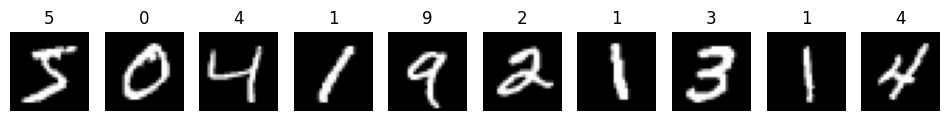

MNIST images AFTER PCA


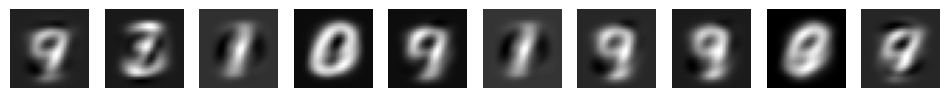

In [26]:
from tensorflow.keras.datasets import mnist
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print('MNIST images BEFORE')
# Display first 10 training images
plt.figure(figsize=(12, 2))  # Wide figure for 10 images in a row
for i in range(10):
    plt.subplot(1, 10, i+1)  # 1 row, 10 columns
    plt.imshow(train_images[i], cmap='gray')
    plt.title(train_labels[i])
    plt.axis('off')
plt.show()


# Reshape data
train_images = np.reshape(train_images, (-1, 784))
test_images = np.reshape(test_images, (-1, 784))

# Normalize data
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

pca = PCA(n_components=3)
pca.fit(train_images)
compressed_images = pca.transform(test_images)
recovered_images = pca.inverse_transform(compressed_images)

# Visualize compressed MNIST digits after PCA
print('MNIST images AFTER PCA')
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(recovered_images[i].reshape(28, 28), cmap="gray")
    plt.axis('off')
plt.show()

### MNIST and Autoencoders 
Source: https://2020machinelearning.medium.com/training-a-simple-autoencoder-on-the-mnist-dataset-a-hand-on-tutorial-46d8a024604c

10000
Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1208 - val_loss: 0.0501
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0455 - val_loss: 0.0355
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0341 - val_loss: 0.0290
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0282 - val_loss: 0.0248
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0244 - val_loss: 0.0219
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0217 - val_loss: 0.0197
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0194 - val_loss: 0.0173
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0171 - val_loss: 0.0155
Epoch 9/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0154 - val_loss: 0.0141
Epoch 10/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0140 - val_loss: 0.0128
Epoch 11/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0127 - val_loss: 0.0115
Epoch 12/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8m

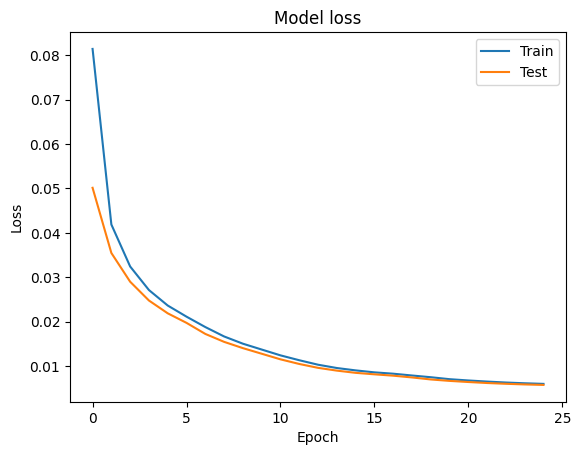

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MNIST images BEFORE Autoencoder


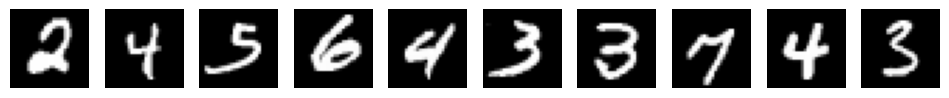

MNIST images AFTER Autoencoder


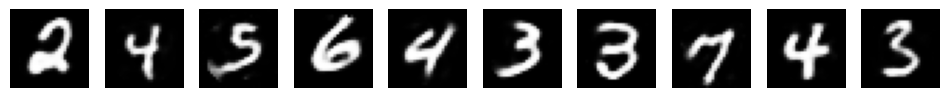

In [22]:
import numpy as np
import tensorflow
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.layers import Layer 


# Load the MNIST dataset
(x_train, train_labels), (x_test, test_labels) = mnist.load_data()

# Normalize the data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.


# Flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

 
# Randomize both the training and test
permutation = np.random.permutation(len(x_train))
x_train, train_labels = x_train[permutation], train_labels[permutation]
permutation = np.random.permutation(len(x_test))
x_test, test_labels = x_test[permutation], test_labels[permutation]


# Create the encoder
list_xtest = [ [x_test[i], test_labels[i]] for i in test_labels] 
print(len(list_xtest)) 

encoder_input = Input(shape=(784,))
encoded = Dense(64, activation='relu')(encoder_input)
encoder = Model(encoder_input, encoded)

# Create the decoder
decoder_input = Input(shape=(64,))
decoded = Dense(784, activation='sigmoid')(decoder_input)
decoder = Model(decoder_input, decoded)

# Create the autoencoder
autoencoder = Model(encoder_input, decoder(encoder(encoder_input)))

lr_schedule = tensorflow.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate = 5e-01, decay_steps = 2500, decay_rate = 0.75,staircase=True) 
tensorflow.keras.optimizers.Adam(learning_rate = lr_schedule,beta_1=0.95,beta_2=0.99,epsilon=1e-01)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')


# Train the autoencoder
history = autoencoder.fit(x_train, x_train,
                epochs=25,
                batch_size=512,
                shuffle=True,
                validation_data=(x_test, x_test))

# Plot the training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

# Plot the test figures vs. predicted figures
decoded_imgs = autoencoder.predict(x_test)

# MNIST digits before
print('MNIST images BEFORE Autoencoder')
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis('off')
plt.show()


# Decoded MNIST digits after PCA
print('MNIST images AFTER Autoencoder')
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis('off')
plt.show()